# Build a Real Transformer LLM from Scratch

This notebook builds a **production-grade GPT-style language model** using modern architecture components.

## Architecture Highlights

- **Transformer Decoder** (GPT-style autoregressive)
- **RMSNorm** instead of LayerNorm (LLaMA/Mistral approach)
- **Rotary Positional Embeddings (RoPE)** for better position encoding
- **SwiGLU Activation** in FFN (PaLM/LLaMA 2-3 approach)
- **Multi-Head Self-Attention** with causal masking
- **KV-Cache** for efficient autoregressive generation
- **Weight Tying** between embeddings and output head

## Model Scale Options

| Config | Params | Embed Dim | Heads | Layers | GPU Requirement |
|--------|--------|-----------|-------|--------|----------------|
| Small  | ~28M   | 384       | 6     | 6      | Colab Free (T4) |
| Medium | ~85M   | 512       | 8     | 8      | Colab Pro |
| Large  | ~165M  | 768       | 12    | 12     | A100 |

## Dataset

- **TinyStories** (roneneldan/TinyStories) - 2.1M short stories for children
- **Tokenizer**: tiktoken GPT-2 encoding (vocab size 50,257)

## Training Features

- AdamW optimizer with cosine LR schedule + warmup
- Mixed precision (FP16) training
- Gradient clipping
- Model checkpointing (best val loss)
- Sample generation during training

## GPU Instructions

**Colab Free Tier (T4)**:
- Go to Runtime → Change runtime type → GPU → T4
- Use **Small** config (default)

**Colab Pro (A100/V100)**:
- Uncomment **Medium** or **Large** config as desired


In [1]:
# Install dependencies
!pip install tiktoken datasets wandb --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import tiktoken
from datasets import load_dataset
import math
import json
import os
from dataclasses import dataclass, asdict
import matplotlib.pyplot as plt
import time
from typing import Optional, Tuple
import numpy as np

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


In [2]:
@dataclass
class LLMConfig:
    """Configuration for the LLM model."""
    # Model architecture
    vocab_size: int = 50257  # GPT-2 tokenizer vocab size
    embed_dim: int = 384     # Embedding dimension
    num_heads: int = 6       # Number of attention heads
    num_layers: int = 6      # Number of transformer layers
    ffn_dim_multiplier: float = 4.0  # FFN hidden dim = embed_dim * multiplier
    max_seq_len: int = 512   # Maximum sequence length
    dropout: float = 0.1     # Dropout probability

    # Training hyperparameters
    batch_size: int = 16
    learning_rate: float = 3e-4
    weight_decay: float = 0.1
    num_epochs: int = 3
    warmup_steps: int = 500
    max_steps: int = 10000
    eval_interval: int = 500
    eval_samples: int = 100

    # Generation
    max_gen_len: int = 256

    def __post_init__(self):
        assert self.embed_dim % self.num_heads == 0, "embed_dim must be divisible by num_heads"

# Configuration options (uncomment desired size)

# Small config (~28M params) - for Colab Free T4
config = LLMConfig(
    embed_dim=384,
    num_heads=6,
    num_layers=6,
    batch_size=16,
    max_seq_len=512
)

# Medium config (~85M params) - for Colab Pro
# config = LLMConfig(
#     embed_dim=512,
#     num_heads=8,
#     num_layers=8,
#     batch_size=12,
#     max_seq_len=512
# )

# Large config (~165M params) - for A100
# config = LLMConfig(
#     embed_dim=768,
#     num_heads=12,
#     num_layers=12,
#     batch_size=8,
#     max_seq_len=512
# )

print(f"Model configuration:")
print(f"  Embedding dim: {config.embed_dim}")
print(f"  Num heads: {config.num_heads}")
print(f"  Num layers: {config.num_layers}")
print(f"  Batch size: {config.batch_size}")
print(f"  Max seq len: {config.max_seq_len}")


Model configuration:
  Embedding dim: 384
  Num heads: 6
  Num layers: 6
  Batch size: 16
  Max seq len: 512


In [3]:
class Tokenizer:
    """Wrapper around tiktoken for easy encoding/decoding."""

    def __init__(self, encoding_name: str = "gpt2"):
        self.enc = tiktoken.get_encoding(encoding_name)
        self.vocab_size = self.enc.n_vocab
        self.eot_token = self.enc.eot_token  # End of text token

    def encode(self, text: str) -> list:
        """Encode text to token IDs."""
        return self.enc.encode(text, allowed_special={'<|endoftext|>'})

    def decode(self, tokens: list) -> str:
        """Decode token IDs to text."""
        return self.enc.decode(tokens)

    def encode_batch(self, texts: list) -> list:
        """Encode a batch of texts."""
        return [self.encode(text) for text in texts]

# Initialize tokenizer
tokenizer = Tokenizer()
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")
print(f"EOT token ID: {tokenizer.eot_token}")

# Demo
sample_text = "Once upon a time, there was a small language model."
tokens = tokenizer.encode(sample_text)
decoded = tokenizer.decode(tokens)
print(f"\nOriginal: {sample_text}")
print(f"Tokens: {tokens[:10]}... (length: {len(tokens)})")
print(f"Decoded: {decoded}")


Tokenizer vocab size: 50257
EOT token ID: 50256

Original: Once upon a time, there was a small language model.
Tokens: [7454, 2402, 257, 640, 11, 612, 373, 257, 1402, 3303]... (length: 12)
Decoded: Once upon a time, there was a small language model.


In [4]:
class TinyStoriesDataset(Dataset):
    """Dataset for TinyStories with proper tokenization and batching."""

    def __init__(self, split='train', max_length=512, num_samples=None):
        print(f"Loading TinyStories dataset ({split} split)...")
        # Load dataset from HuggingFace
        self.dataset = load_dataset('roneneldan/TinyStories', split=split)

        if num_samples:
            self.dataset = self.dataset.select(range(min(num_samples, len(self.dataset))))

        self.max_length = max_length
        self.tokenizer = Tokenizer()

        # Pre-tokenize all stories
        print(f"Tokenizing {len(self.dataset)} stories...")
        self.tokenized_data = []

        for i, example in enumerate(self.dataset):
            if i % 10000 == 0 and i > 0:
                print(f"  Processed {i} stories...")

            # Encode story and add EOT token
            tokens = self.tokenizer.encode(example['text'])
            tokens.append(self.tokenizer.eot_token)
            self.tokenized_data.extend(tokens)

        print(f"Total tokens: {len(self.tokenized_data):,}")

        # Create sliding window samples
        self.samples = []
        for i in range(0, len(self.tokenized_data) - max_length, max_length // 2):
            self.samples.append(self.tokenized_data[i:i + max_length + 1])

        print(f"Created {len(self.samples)} training samples\n")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        x = torch.tensor(sample[:-1], dtype=torch.long)
        y = torch.tensor(sample[1:], dtype=torch.long)
        return x, y

# Create datasets and dataloaders
print("Preparing training data...")
train_dataset = TinyStoriesDataset(split='train', max_length=config.max_seq_len, num_samples=50000)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2)

print("Preparing validation data...")
val_dataset = TinyStoriesDataset(split='validation', max_length=config.max_seq_len, num_samples=5000)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Preparing training data...
Loading TinyStories dataset (train split)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

...

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Tokenizing 50000 stories...
  Processed 10000 stories...
  Processed 20000 stories...
  Processed 30000 stories...
  Processed 40000 stories...
Total tokens: 11,089,438
Created 43317 training samples

Preparing validation data...
Loading TinyStories dataset (validation split)...
Tokenizing 5000 stories...
Total tokens: 1,000,238
Created 3906 training samples


Train batches: 2708
Val batches: 245


In [7]:
class RotaryEmbedding(nn.Module):
    """Rotary Position Embeddings (RoPE) from RoFormer."""

    def __init__(self, dim: int, max_seq_len: int = 2048, base: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_seq_len = max_seq_len
        self.base = base

        # Precompute frequencies
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

        # Build cache
        self._build_cache(max_seq_len)

    def _build_cache(self, max_seq_len: int):
        t = torch.arange(max_seq_len, dtype=self.inv_freq.dtype)
        freqs = torch.outer(t, self.inv_freq)
        # FIX: The original code used `emb = torch.cat([freqs, freqs], dim=-1)`, which doubled the last dimension.
        # RoPE applies to half the dimension for the complex-like rotation, so cos/sin should match freqs directly.
        self.register_buffer('cos_cached', freqs.cos(), persistent=False)
        self.register_buffer('sin_cached', freqs.sin(), persistent=False)

    def forward(self, x: torch.Tensor, seq_len: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return (
            self.cos_cached[:seq_len].to(x.dtype),
            self.sin_cached[:seq_len].to(x.dtype)
        )

def apply_rotary_emb(x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
    """Apply rotary embeddings to input tensor."""
    # Split into two halves
    x1, x2 = x.chunk(2, dim=-1)
    # Apply rotation
    rotated = torch.cat([
        x1 * cos - x2 * sin,
        x1 * sin + x2 * cos
    ], dim=-1)
    return rotated

# ---------- Multi-Head Self-Attention with KV-Cache ----------
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention with causal masking and KV-cache support."""

    def __init__(self, config: LLMConfig):
        super().__init__()
        self.num_heads = config.num_heads
        self.head_dim = config.embed_dim // config.num_heads
        self.embed_dim = config.embed_dim

        # Q, K, V projections
        self.q_proj = nn.Linear(config.embed_dim, config.embed_dim, bias=False)
        self.k_proj = nn.Linear(config.embed_dim, config.embed_dim, bias=False)
        self.v_proj = nn.Linear(config.embed_dim, config.embed_dim, bias=False)
        self.out_proj = nn.Linear(config.embed_dim, config.embed_dim, bias=False)

        self.dropout = nn.Dropout(config.dropout)
        self.rotary_emb = RotaryEmbedding(self.head_dim, config.max_seq_len)

    def forward(
        self,
        x: torch.Tensor,
        kv_cache: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        use_cache: bool = False
    ) -> Tuple[torch.Tensor, Optional[Tuple[torch.Tensor, torch.Tensor]]]:
        batch_size, seq_len, _ = x.shape

        # Project to Q, K, V
        q = self.q_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Apply rotary embeddings
        cos, sin = self.rotary_emb(x, seq_len)
        # cos and sin are now (seq_len, head_dim / 2)
        # q and k are (B, H, S, head_dim)
        # apply_rotary_emb will split q and k into (B, H, S, head_dim / 2) for x1, x2
        # then perform element-wise multiplication with cos and sin
        q = apply_rotary_emb(q, cos.unsqueeze(0).unsqueeze(0), sin.unsqueeze(0).unsqueeze(0)) # Unsqueeze for broadcasting to (B, H, S, D_h/2)
        k = apply_rotary_emb(k, cos.unsqueeze(0).unsqueeze(0), sin.unsqueeze(0).unsqueeze(0))

        # Handle KV cache for generation
        if kv_cache is not None:
            k_cache, v_cache = kv_cache
            k = torch.cat([k_cache, k], dim=2)
            v = torch.cat([v_cache, v], dim=2)

        new_cache = (k, v) if use_cache else None

        # Attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Causal mask
        if kv_cache is None:
            mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
            scores = scores.masked_fill(mask, float('-inf'))

        # Softmax and weighted sum
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        out = torch.matmul(attn_weights, v)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_dim)
        out = self.out_proj(out)

        return out, new_cache

# ---------- SwiGLU Feed-Forward Network ----------
class SwiGLUFFN(nn.Module):
    """SwiGLU feed-forward network (used in LLaMA 2/3, PaLM)."""

    def __init__(self, config: LLMConfig):
        super().__init__()
        hidden_dim = int(config.embed_dim * config.ffn_dim_multiplier)

        # SwiGLU requires two projections for gating
        self.w1 = nn.Linear(config.embed_dim, hidden_dim, bias=False)
        self.w2 = nn.Linear(hidden_dim, config.embed_dim, bias=False)
        self.w3 = nn.Linear(config.embed_dim, hidden_dim, bias=False)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # SwiGLU: swish(W1(x)) ⊙ W3(x), then W2
        swish_out = F.silu(self.w1(x))
        gated = swish_out * self.w3(x)
        out = self.w2(gated)
        return self.dropout(out)

# ---------- Transformer Block ----------
class TransformerBlock(nn.Module):
    """Single transformer block with attention and FFN."""

    def __init__(self, config: LLMConfig):
        super().__init__()
        self.attention = MultiHeadAttention(config)
        self.feed_forward = SwiGLUFFN(config)
        self.attention_norm = RMSNorm(config.embed_dim)
        self.ffn_norm = RMSNorm(config.embed_dim)

    def forward(
        self,
        x: torch.Tensor,
        kv_cache: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        use_cache: bool = False
    ) -> Tuple[torch.Tensor, Optional[Tuple[torch.Tensor, torch.Tensor]]]:
        # Self-attention with residual
        attn_out, new_cache = self.attention(self.attention_norm(x), kv_cache, use_cache)
        x = x + attn_out

        # FFN with residual
        x = x + self.feed_forward(self.ffn_norm(x))

        return x, new_cache

# ---------- Main LLM Model ----------
class RealLLM(nn.Module):
    """Complete GPT-style transformer language model."""

    def __init__(self, config: LLMConfig):
        super().__init__()
        self.config = config

        # Token embeddings
        self.token_embeddings = nn.Embedding(config.vocab_size, config.embed_dim)

        # Transformer blocks
        self.layers = nn.ModuleList([TransformerBlock(config) for _ in range(config.num_layers)])

        # Final norm
        self.norm = RMSNorm(config.embed_dim)

        # Output head (tied with input embeddings)
        self.lm_head = nn.Linear(config.embed_dim, config.vocab_size, bias=False)
        self.lm_head.weight = self.token_embeddings.weight  # Weight tying

        # Initialize weights
        self.apply(self._init_weights)

        # Apply special scaled init to residual projections (GPT-2 style)
        for name, param in self.named_parameters():
            if name.endswith('out_proj.weight') or name.endswith('w2.weight'):
                nn.init.normal_(param, mean=0.0, std=0.02 / math.sqrt(2 * config.num_layers))

    def _init_weights(self, module):
        """Initialize weights (GPT-2 style)."""
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(
        self,
        input_ids: torch.Tensor,
        kv_caches: Optional[list] = None,
        use_cache: bool = False
    ) -> Tuple[torch.Tensor, Optional[list]]:
        # Token embeddings
        x = self.token_embeddings(input_ids)

        # Pass through transformer blocks
        new_caches = [] if use_cache else None
        for i, layer in enumerate(self.layers):
            cache = kv_caches[i] if kv_caches else None
            x, new_cache = layer(x, cache, use_cache)
            if use_cache:
                new_caches.append(new_cache)

        # Final norm and projection
        x = self.norm(x)
        logits = self.lm_head(x)

        return logits, new_caches

    def count_parameters(self):
        """Count total trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Initialize model
model = RealLLM(config).to(device)
total_params = model.count_parameters()
print(f"\nModel initialized!")
print(f"Total parameters: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Model size: ~{total_params * 4 / 1e9:.2f} GB (FP32)")


Model initialized!
Total parameters: 33,459,456 (33.5M)
Model size: ~0.13 GB (FP32)


In [8]:
# ========== TRAINING FUNCTIONS ==========

def get_lr(step: int, config: LLMConfig) -> float:
    """Cosine learning rate schedule with linear warmup."""
    if step < config.warmup_steps:
        # Linear warmup
        return config.learning_rate * (step + 1) / config.warmup_steps
    elif step < config.max_steps:
        # Cosine decay
        progress = (step - config.warmup_steps) / (config.max_steps - config.warmup_steps)
        return config.learning_rate * 0.5 * (1 + math.cos(math.pi * progress))
    else:
        return config.learning_rate * 0.1  # Minimum LR

def evaluate(model, dataloader, device, num_batches=None):
    """Evaluate model on validation set."""
    model.eval()
    total_loss = 0
    num_batches_eval = 0

    with torch.no_grad():
        for i, (x, y) in enumerate(dataloader):
            if num_batches and i >= num_batches:
                break

            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            loss = F.cross_entropy(logits.view(-1, config.vocab_size), y.view(-1))
            total_loss += loss.item()
            num_batches_eval += 1

    model.train()
    avg_loss = total_loss / num_batches_eval
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

def generate_sample(model, tokenizer, prompt, max_length=100, temperature=0.8, top_k=50, device='cuda'):
    """Generate text from a prompt."""
    model.eval()
    tokens = tokenizer.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_length):
            # Get logits for last token
            logits, _ = model(tokens[:, -config.max_seq_len:])
            logits = logits[:, -1, :] / temperature

            # Top-k sampling
            if top_k > 0:
                top_k_logits, top_k_indices = torch.topk(logits, top_k)
                logits = torch.full_like(logits, float('-inf'))
                logits.scatter_(1, top_k_indices, top_k_logits)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            # Stop at EOT
            if next_token.item() == tokenizer.eot_token:
                break

            tokens = torch.cat([tokens, next_token], dim=1)

    model.train()
    return tokenizer.decode(tokens[0].tolist())

def train(model, train_loader, val_loader, config, device):
    """Main training loop."""
    print("\n" + "="*60)
    print("STARTING TRAINING")
    print("="*60)

    # Setup optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        betas=(0.9, 0.95),
        weight_decay=config.weight_decay
    )

    # Mixed precision scaler
    device_type = "cuda" if device.type == "cuda" else "cpu"
    scaler = GradScaler(device_type)

    # Training state
    global_step = 0
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    val_perplexities = []

    # Create output directory
    os.makedirs('outputs', exist_ok=True)

    model.train()

    for epoch in range(config.num_epochs):
        print(f"\n{'='*60}")
        print(f"EPOCH {epoch + 1}/{config.num_epochs}")
        print(f"{'='*60}")

        epoch_start = time.time()
        total_tokens = 0

        for batch_idx, (x, y) in enumerate(train_loader):
            if global_step >= config.max_steps:
                break

            x, y = x.to(device), y.to(device)

            # Update learning rate
            lr = get_lr(global_step, config)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            # Forward pass with mixed precision
            with autocast(device_type=device_type):
                logits, _ = model(x)
                loss = F.cross_entropy(logits.view(-1, config.vocab_size), y.view(-1))

            # Backward pass
            optimizer.zero_grad()
            scaler.scale(loss).backward()

            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            # Track metrics
            train_losses.append(loss.item())
            total_tokens += x.numel()
            global_step += 1

            # Logging
            if batch_idx % 50 == 0:
                elapsed = time.time() - epoch_start
                tokens_per_sec = total_tokens / elapsed if elapsed > 0 else 0
                print(f"Step {global_step:5d} | Loss: {loss.item():.4f} | LR: {lr:.2e} | {tokens_per_sec:.0f} tok/s")

            # Evaluation
            if global_step % config.eval_interval == 0:
                print(f"\n{'='*60}")
                print(f"EVALUATION at step {global_step}")
                print(f"{'='*60}")

                val_loss, val_ppl = evaluate(model, val_loader, device, num_batches=50)
                val_losses.append(val_loss)
                val_perplexities.append(val_ppl)

                print(f"Val Loss: {val_loss:.4f} | Val Perplexity: {val_ppl:.2f}")

                # Save best model
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save({
                        'step': global_step,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': val_loss,
                        'config': asdict(config)
                    }, 'outputs/best_model.pt')
                    print(f"✓ Saved best model (val_loss: {val_loss:.4f})")

                # Generate sample
                print(f"\nSample generation:")
                sample = generate_sample(model, tokenizer, "Once upon a time", max_length=80, device=device)
                print(f"{sample}\n")
                print(f"{'='*60}\n")

        # End of epoch summary
        epoch_time = time.time() - epoch_start
        print(f"\nEpoch {epoch + 1} completed in {epoch_time/60:.1f} minutes")
        print(f"Tokens processed: {total_tokens:,}")

    print(f"\n{'='*60}")
    print("TRAINING COMPLETED!")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"{'='*60}\n")

    # Save training history
    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_perplexities': val_perplexities,
        'best_val_loss': best_val_loss
    }
    with open('outputs/training_history.json', 'w') as f:
        json.dump(history, f, indent=2)

    return history

# Start training
history = train(model, train_loader, val_loader, config, device)



STARTING TRAINING

EPOCH 1/3
Step     1 | Loss: 10.8941 | LR: 6.00e-07 | 6096 tok/s
Step    51 | Loss: 9.3484 | LR: 3.06e-05 | 26091 tok/s
Step   101 | Loss: 7.7145 | LR: 6.06e-05 | 26846 tok/s
Step   151 | Loss: 6.0735 | LR: 9.06e-05 | 27048 tok/s
Step   201 | Loss: 4.8460 | LR: 1.21e-04 | 27143 tok/s
Step   251 | Loss: 4.2044 | LR: 1.51e-04 | 27195 tok/s
Step   301 | Loss: 3.8732 | LR: 1.81e-04 | 27220 tok/s
Step   351 | Loss: 3.6397 | LR: 2.11e-04 | 27219 tok/s
Step   401 | Loss: 3.5275 | LR: 2.41e-04 | 27194 tok/s
Step   451 | Loss: 3.1795 | LR: 2.71e-04 | 27167 tok/s

EVALUATION at step 500
Val Loss: 3.1382 | Val Perplexity: 23.06
✓ Saved best model (val_loss: 3.1382)

Sample generation:
Once upon a time, there was a little girl named Lily. She loved to keep one things and make very much. One day, she saw an idea and asked Lily to help make a long special house to make a little girl too. Lily said, "What's wrong, we can't find you. And you can make you a good friend."

Lily felt 

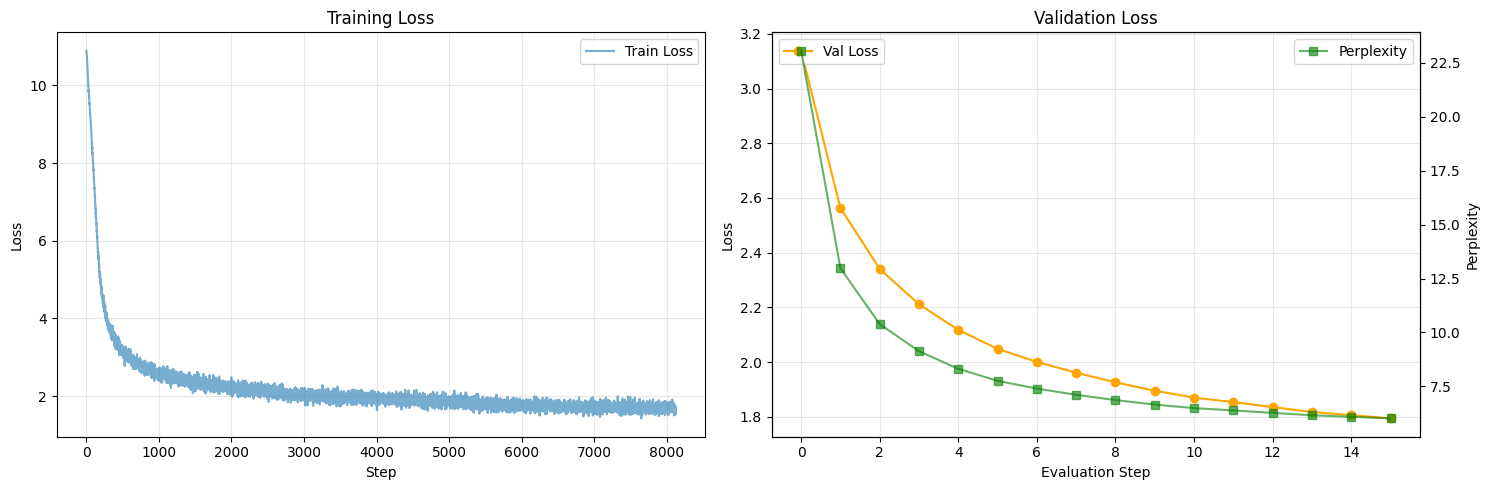

Best validation loss: 1.7943
Final perplexity: 6.02


In [9]:
# ========== VISUALIZATION ==========

# Plot training and validation loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training loss
ax1.plot(history['train_losses'], alpha=0.6, label='Train Loss')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Validation loss and perplexity
ax2.plot(history['val_losses'], 'o-', label='Val Loss', color='orange')
ax2.set_xlabel('Evaluation Step')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss')
ax2_twin = ax2.twinx()
ax2_twin.plot(history['val_perplexities'], 's-', label='Perplexity', color='green', alpha=0.6)
ax2_twin.set_ylabel('Perplexity')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best validation loss: {history['best_val_loss']:.4f}")
print(f"Final perplexity: {history['val_perplexities'][-1]:.2f}")


In [10]:
# ========== TEXT GENERATION ==========

# Load best model
checkpoint = torch.load('outputs/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model from step {checkpoint['step']} (val_loss: {checkpoint['loss']:.4f})\n")

def generate(
    prompt: str,
    max_length: int = 200,
    temperature: float = 0.8,
    top_k: int = 50,
    top_p: float = 0.9
) -> str:
    """Generate text with temperature, top-k, and top-p sampling."""
    model.eval()
    tokens = tokenizer.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_length):
            # Get logits for last token
            logits, _ = model(tokens[:, -config.max_seq_len:])
            logits = logits[:, -1, :] / temperature

            # Top-k filtering
            if top_k > 0:
                top_k_logits, top_k_indices = torch.topk(logits, min(top_k, logits.size(-1)))
                logits = torch.full_like(logits, float('-inf'))
                logits.scatter_(1, top_k_indices, top_k_logits)

            # Top-p (nucleus) filtering
            if top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

                # Remove tokens with cumulative probability above the threshold
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = 0

                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                logits = logits.masked_fill(indices_to_remove, float('-inf'))

            # Sample from the filtered distribution
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            # Stop at EOT
            if next_token.item() == tokenizer.eot_token:
                break

            tokens = torch.cat([tokens, next_token], dim=1)

    return tokenizer.decode(tokens[0].tolist())

def chat(prompt: str, temperature: float = 0.8, max_length: int = 200):
    """Simple chat interface."""
    print(f"\nPrompt: {prompt}")
    print(f"{'='*60}")
    response = generate(prompt, max_length=max_length, temperature=temperature)
    print(response)
    print(f"{'='*60}\n")
    return response

# Example generations
print("\n" + "="*60)
print("EXAMPLE GENERATIONS")
print("="*60)

prompts = [
    "Once upon a time, there was a little girl",
    "The brave knight went on an adventure",
    "In a magical forest,"
]

for prompt in prompts:
    chat(prompt, temperature=0.8, max_length=150)


Loaded best model from step 8000 (val_loss: 1.7943)


EXAMPLE GENERATIONS

Prompt: Once upon a time, there was a little girl
Once upon a time, there was a little girl named Lily. She loved to play in the park with her friends. One day, Lily's mom told her they were going to a special event in the park. Lily was so excited to see all the pretty things in the park.

At the park, Lily saw lots of people running around and having fun. But then, she saw a boy who was crying. Lily felt sad for him and wanted to help him. She remembered that she had a new toy that could make people happy.

Lily ran to the boy and asked if he could borrow her toy. The boy said yes and they all played together. Lily was so happy and grateful that she learned something new. She realized that she could always count on her mom to


Prompt: The brave knight went on an adventure
The brave knight went on an adventure, but he couldn't find it anywhere. He looked and looked, but he couldn't find it. He felt very sad.



In [11]:
# ========== INTERACTIVE CHAT MODE ==========

print("\n" + "="*60)
print("INTERACTIVE CHAT MODE")
print("="*60)
print("Enter prompts to generate stories. Type 'quit' to exit.\n")

while True:
    try:
        user_prompt = input("Your prompt: ").strip()

        if user_prompt.lower() in ['quit', 'exit', 'q']:
            print("Goodbye!")
            break

        if not user_prompt:
            continue

        # Generate response
        response = generate(user_prompt, max_length=200, temperature=0.8)
        print(f"\n{response}\n")
        print("-" * 60 + "\n")

    except KeyboardInterrupt:
        print("\nGoodbye!")
        break
    except Exception as e:
        print(f"Error: {e}")



INTERACTIVE CHAT MODE
Enter prompts to generate stories. Type 'quit' to exit.

Your prompt: hi

hi and said, "Yes, I would like to help. Let's be friends."

The fairy said, "That would be fun, but don't forget to be kind."

Jack and the fairy looked at each other and smiled. They had a lot of fun and were happy to be friends.

------------------------------------------------------------

Your prompt: exit
Goodbye!


In [18]:
# ========== SAVE & EXPORT ==========

print("\n" + "="*60)
print("SAVING MODEL AND ARTIFACTS")
print("="*60 + "\n")

# Save model weights
torch.save(model.state_dict(), 'outputs/model_weights.pt')
print("✓ Saved model weights to outputs/model_weights.pt")

# Save config
with open('outputs/config.json', 'w') as f:
    json.dump(asdict(config), f, indent=2)
print("✓ Saved config to outputs/config.json")

# Save training log
with open('outputs/training_log.txt', 'w') as f:
    f.write(f"Model: RealLLM\n")
    f.write(f"Parameters: {model.count_parameters():,}\n")
    f.write(f"Config: {config.embed_dim}d, {config.num_heads}h, {config.num_layers}L\n")
    f.write(f"\nTraining Stats:\n")
    f.write(f"  Total steps: {len(history['train_losses'])}\n")
    f.write(f"  Best val loss: {history['best_val_loss']:.4f}\n")
    f.write(f"  Final perplexity: {history['val_perplexities'][-1]:.2f}\n")
print("✓ Saved training log to outputs/training_log.txt")

# Create model card
model_card = f"""# RealLLM Model Card

## Model Details

- **Model Type**: GPT-style Transformer Language Model
- **Architecture**: Decoder-only transformer with modern components
- **Parameters**: {model.count_parameters():,} ({model.count_parameters()/1e6:.1f}M)
- **Embedding Dimension**: {config.embed_dim}
- **Attention Heads**: {config.num_heads}
- **Layers**: {config.num_layers}
- **Vocabulary Size**: {config.vocab_size} (tiktoken GPT-2 encoding)

## Architecture Components

- **Normalization**: RMSNorm (LLaMA-style)
- **Position Encoding**: Rotary Positional Embeddings (RoPE)
- **Activation**: SwiGLU in feed-forward networks
- **Attention**: Multi-head self-attention with causal masking
- **Optimization**: Weight tying between embeddings and output head

## Training

- **Dataset**: TinyStories (roneneldan/TinyStories)
- **Optimizer**: AdamW (betas=0.9,0.95, weight_decay=0.1)
- **Learning Rate**: {config.learning_rate} with cosine schedule and warmup
- **Mixed Precision**: FP16 training with gradient scaling
- **Gradient Clipping**: Max norm 1.0
- **Best Validation Loss**: {history['best_val_loss']:.4f}
- **Final Perplexity**: {history['val_perplexities'][-1]:.2f}

## Usage

```python
# Load model
model = RealLLM(config)
model.load_state_dict(torch.load('model_weights.pt'))
model.eval()

# Generate text
prompt = "Once upon a time"
output = generate(prompt, max_length=200, temperature=0.8)
```

## Limitations

- Trained only on TinyStories (simple children's stories)
- Limited to 512 token context window
- Small vocabulary compared to production models

## License

This model is for educational purposes.
"""

with open('outputs/MODEL_CARD.md', 'w') as f:
    f.write(model_card)
print("✓ Saved model card to outputs/MODEL_CARD.md")

# Create zip file for download
import shutil
shutil.make_archive('real_llm_model', 'zip', 'outputs')
print("✓ Created zip file: real_llm_model.zip\n")

# Download from Colab
try:
    from google.colab import files
    files.download('real_llm_model.zip')
    print("✓ Download started! Check your browser downloads.")
except ImportError:
    print("Not running in Colab - files saved to outputs/ directory")

print("\n" + "="*60)
print("ALL DONE!")
print("="*60)
print(f"\nModel artifacts saved in 'outputs/' directory:")
print("  - best_model.pt (full checkpoint)")
print("  - model_weights.pt (state dict)")
print("  - config.json")
print("  - training_history.json")
print("  - training_log.txt")
print("  - MODEL_CARD.md")
print("  - training_curves.png")



SAVING MODEL AND ARTIFACTS

✓ Saved model weights to outputs/model_weights.pt
✓ Saved config to outputs/config.json
✓ Saved training log to outputs/training_log.txt
✓ Saved model card to outputs/MODEL_CARD.md
✓ Created zip file: real_llm_model.zip



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started! Check your browser downloads.

ALL DONE!

Model artifacts saved in 'outputs/' directory:
  - best_model.pt (full checkpoint)
  - model_weights.pt (state dict)
  - config.json
  - training_history.json
  - training_log.txt
  - MODEL_CARD.md
  - training_curves.png
